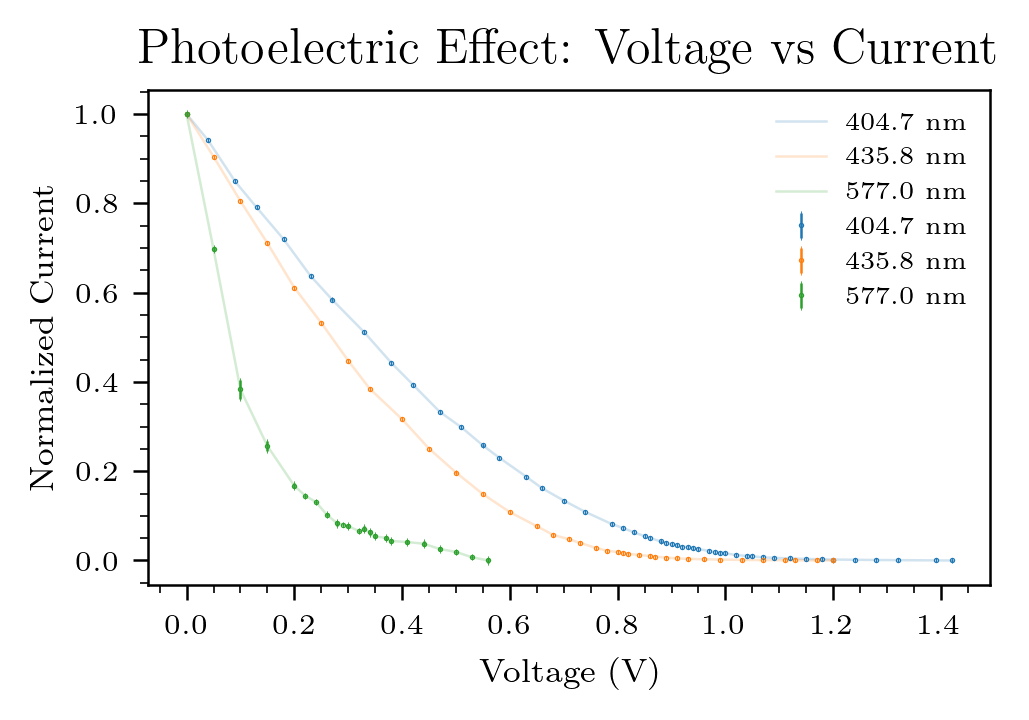

In [147]:
import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt
import warnings
from scipy.interpolate import UnivariateSpline
from scipy.optimize import brentq
with warnings.catch_warnings():
    warnings.simplefilter("ignore", DeprecationWarning)
    from scipy.odr import ODR, Model, RealData

plt.style.use("./jlab.mplstyle")

k        = 4
smoothing = 10000000
c        = 299792458   # m/s
wave_unc = 2           # nm
e        = 1.602e-19   # C

wavelengths = np.array([404.7, 435.8, 577.0])
colors      = plt.rcParams["axes.prop_cycle"].by_key()["color"]
wl_colors   = {wl: colors[i] for i, wl in enumerate(wavelengths)}
frequencies = c / (wavelengths * 1e-9)
freq_unc    = (c / (wavelengths * 1e-9)**2) * wave_unc * 1e-9
V_stops     = []
V_stops_unc = []

def load_iv_data(wl_nm):
    df = pd.read_csv(f"{wl_nm}.csv")
    I  = df[["I1", "I2", "I3", "I4", "I5"]].values
    return df["V"].values, I.mean(axis=1), scipy.stats.sem(I, axis=1)

datasets = {}
for wl in wavelengths:
    V, I, u = load_iv_data(wl)
    datasets[wl] = V, (I - I.min()) / (I.max()-I.min()), u / (I.max()-I.min())

fig, ax = plt.subplots(figsize=(3.5, 2.5))
for wl, (V, I, u) in datasets.items():
    ax.errorbar(V, I, yerr=u, fmt="o", capsize=0.1, markersize=0.3,
                color=wl_colors[wl], label=f"{wl} nm")
    ax.plot(V, I, markersize=0.3, color=wl_colors[wl], alpha=0.2, label=f"{wl} nm")
    
ax.set_xlabel("Voltage (V)")
ax.set_ylabel("Normalized Current")
ax.set_title("Photoelectric Effect: Voltage vs Current")
ax.legend()
plt.tight_layout()
plt.show()


404.7 nm: V_stop = 1.2562 V
435.8 nm: V_stop = 1.0235 V
577.0 nm: V_stop = 0.4145 V

h/e = 3.7582e-15 V·s
h   = 6.0206e-34 J·s  (true: 6.626×10⁻³⁴)
δh  = 2.3890e-35 J·s


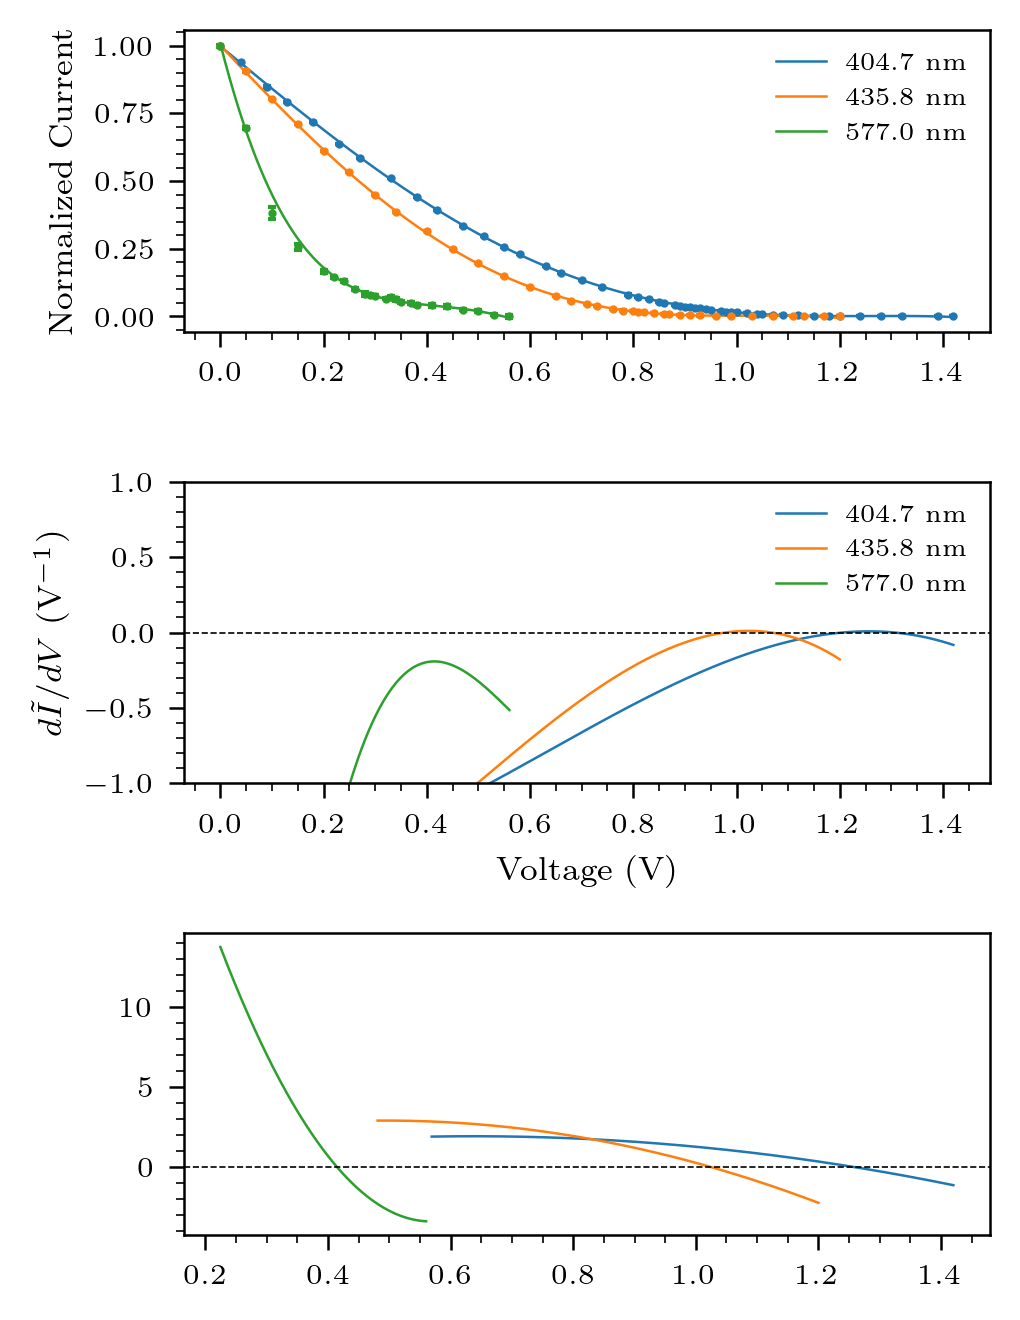

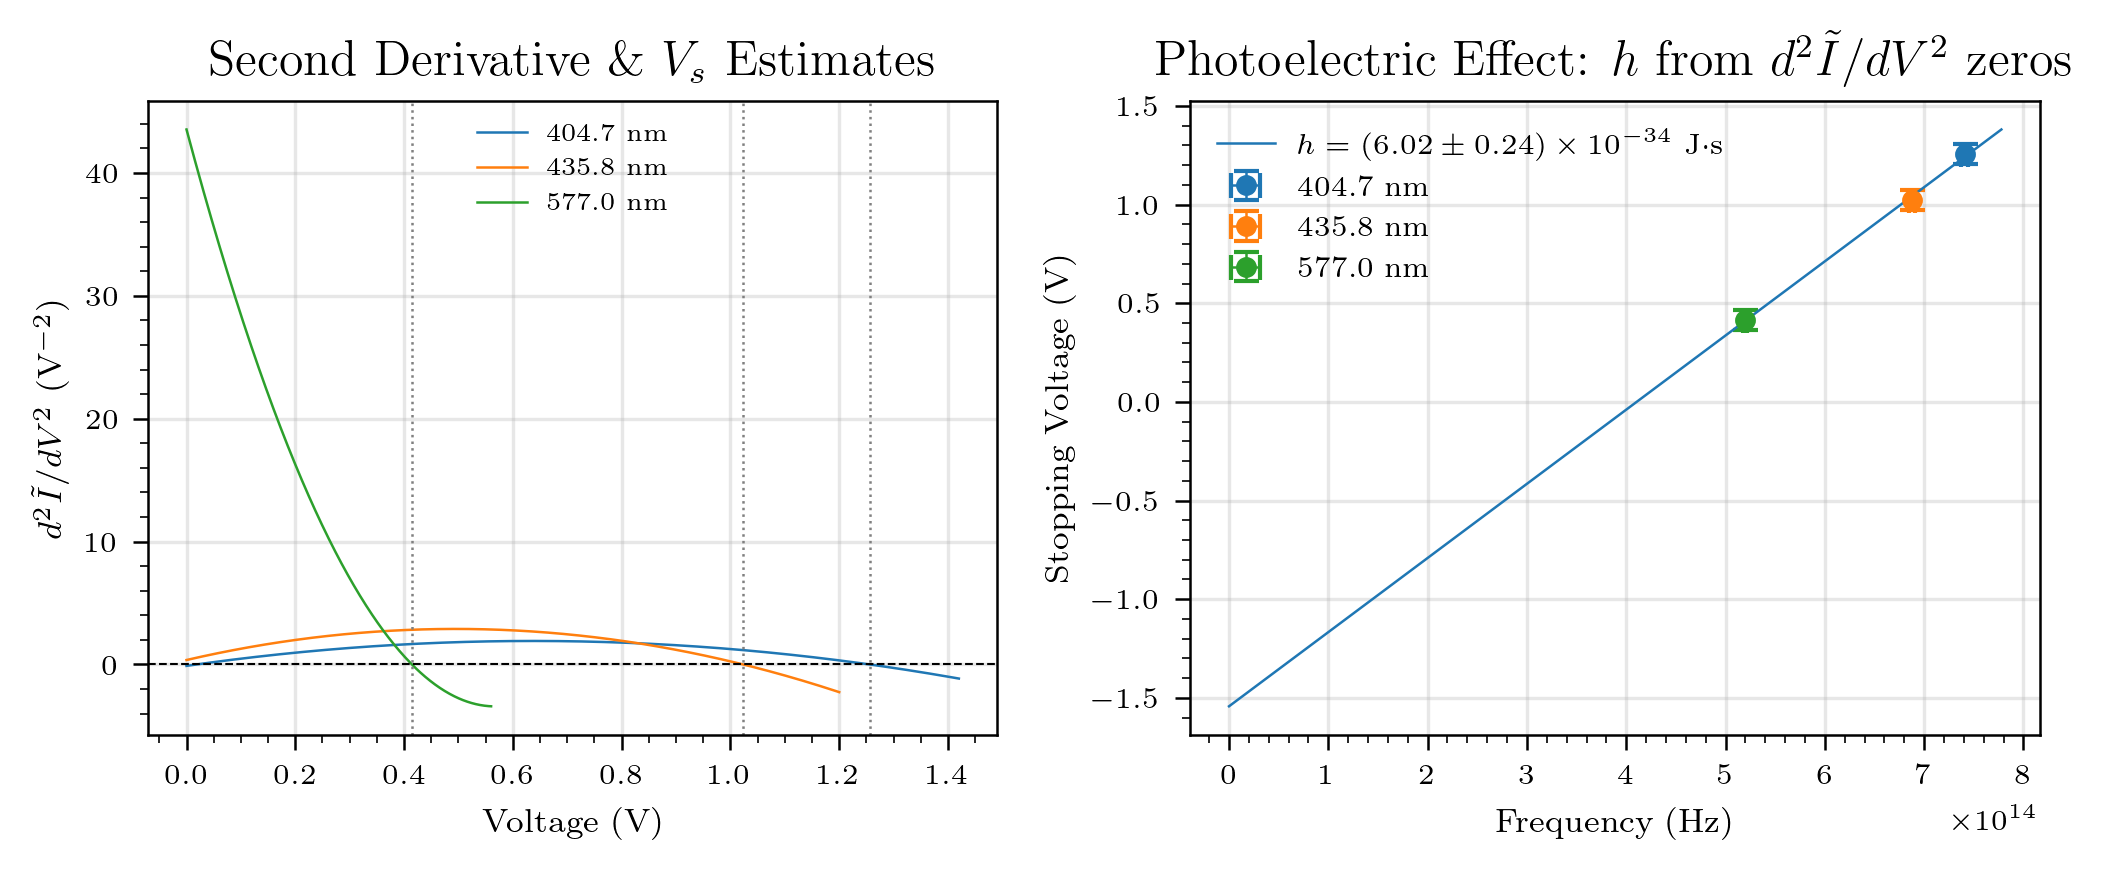

In [148]:






fig1, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=False, figsize=(3.5, 4.5))
fig2, (ax4, ax5)      = plt.subplots(1, 2, figsize=(7, 3))

for wl, (V, I, u) in datasets.items():
    color   = wl_colors[wl]
    w       = np.where(u > 0, 1 / u, 1.0)
    us      = UnivariateSpline(V, I, w=w, k=k, s=smoothing)
    d1      = us.derivative()
    d2      = d1.derivative()
    v_fine  = np.linspace(V[0], V[-1], 500)
    d2_fine = d2(v_fine)

    ax1.errorbar(V, I, yerr=u, fmt="o", markersize=1, color=color)
    ax1.plot(v_fine, us(v_fine), color=color, label=f"{wl} nm")
    ax2.plot(v_fine, d1(v_fine), color=color, label=f"{wl} nm")
    ax3.plot(v_fine[200:], d2_fine[200:], color=color, label=f"{wl} nm")
    ax4.plot(v_fine, d2_fine, color=color, label=f"{wl} nm")

    v_lo     = V[0] + 0.4 * (V[-1] - V[0])
    v_search = np.linspace(v_lo, V[-1], 2000)
    idx      = np.where(np.diff(np.sign(d2(v_search))))[0]
    V_stop   = brentq(d2, v_search[idx[0]], v_search[idx[0] + 1]) if idx.size > 0 else np.nan
    V_stops.append(V_stop)
    V_stops_unc.append(0.05)   # placeholder
    print(f"{wl} nm: V_stop = {V_stop:.4f} V")

ax2.axhline(0, color="k", linewidth=0.4, linestyle="--")
ax3.axhline(0, color="k", linewidth=0.4, linestyle="--")
ax1.set_ylabel("Normalized Current")
ax1.legend()
ax2.set_xlabel("Voltage (V)")
ax2.set_ylabel(r"$d\tilde{I}/dV$ (V$^{-1}$)")
ax2.set_ylim(-1.0, 1.0)
ax2.legend()
fig1.tight_layout()

V_stops     = np.array(V_stops)
V_stops_unc = np.array(V_stops_unc)

def linear_odr(beta, x):
    return beta[0] * x + beta[1]

with warnings.catch_warnings():
    warnings.simplefilter("ignore", DeprecationWarning)
    data       = RealData(frequencies, V_stops, sx=freq_unc, sy=V_stops_unc)
    odr_result = ODR(data, Model(linear_odr), beta0=[3.8e-15, -1.0]).run()

m, b   = odr_result.beta
m_err  = odr_result.sd_beta[0]
h_est  = e * m
h_err  = e * m_err

print(f"\nh/e = {m:.4e} V·s")
print(f"h   = {h_est:.4e} J·s  (true: 6.626×10⁻³⁴)")
print(f"δh  = {h_err:.4e} J·s")

ax4.axhline(0, color="k", linewidth=0.5, linestyle="--")
for V_s in V_stops:
    ax4.axvline(V_s, color="gray", linewidth=0.6, linestyle=":")
ax4.set_xlabel("Voltage (V)")
ax4.set_ylabel(r"$d^2\tilde{I}/dV^2$ (V$^{-2}$)")
ax4.set_title(r"Second Derivative \& $V_s$ Estimates")
ax4.legend(fontsize=6)
ax4.grid(True, alpha=0.3)

for wl, V_s, V_s_u, f, f_u in zip(wavelengths, V_stops, V_stops_unc, frequencies, freq_unc):
    ax5.errorbar(f, V_s, yerr=V_s_u, xerr=f_u, fmt="o", markersize=4, capsize=3,
                 color=wl_colors[wl], label=f"{wl} nm")
f_fit = np.linspace(0, frequencies.max() * 1.05, 200)
ax5.plot(f_fit, m * f_fit + b,
         label=rf"$h = ({h_est/1e-34:.2f} \pm {h_err/1e-34:.2f}) \times 10^{{-34}}$ J·s")
ax5.set_xlabel("Frequency (Hz)")
ax5.set_ylabel("Stopping Voltage (V)")
ax5.set_title(r"Photoelectric Effect: $h$ from $d^2\tilde{I}/dV^2$ zeros")
ax5.legend(fontsize=7)
ax5.grid(True, alpha=0.3)

fig2.tight_layout()
plt.show()


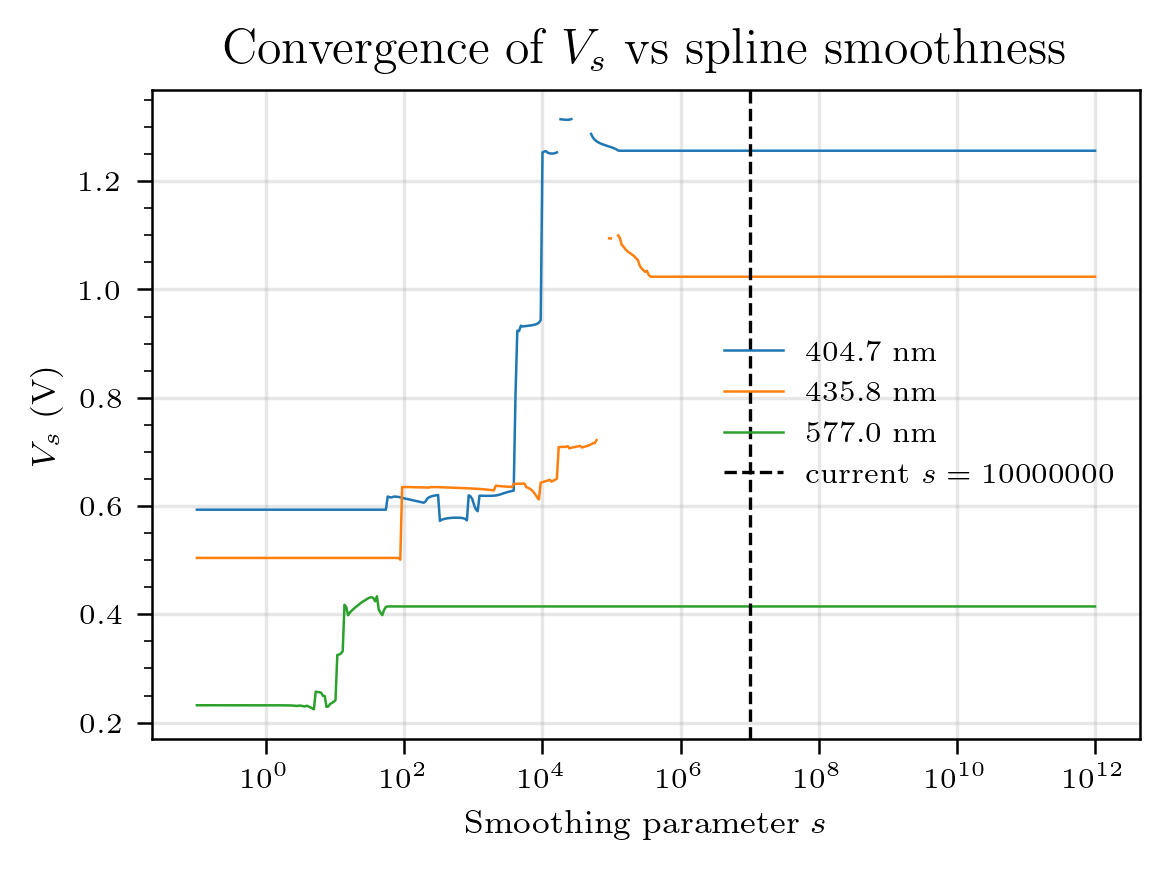

In [149]:
s_values = np.logspace(-1, 12, 500)

fig, ax = plt.subplots(figsize=(4, 3))

for wl, (V, I, u) in datasets.items():
    w        = np.where(u > 0, 1 / u, 1.0)
    v_lo     = V[0] + 0.4 * (V[-1] - V[0])
    v_search = np.linspace(v_lo, V[-1], 2000)

    vstops = []
    for s in s_values:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            d2 = UnivariateSpline(V, I, w=w, k=k, s=s).derivative().derivative()
        idx = np.where(np.diff(np.sign(d2(v_search))))[0]
        vstops.append(brentq(d2, v_search[idx[0]], v_search[idx[0] + 1]) if idx.size > 0 else np.nan)

    ax.plot(s_values, vstops, color=wl_colors[wl], label=f"{wl} nm")

ax.axvline(smoothing, color="k", linewidth=0.8, linestyle="--", label=f"current $s={smoothing}$")
ax.set_xscale("log")
ax.set_xlabel("Smoothing parameter $s$")
ax.set_ylabel("$V_s$ (V)")
ax.set_title(r"Convergence of $V_s$ vs spline smoothness")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
